In [33]:
import requests
import json
import sys
from pathlib import Path

def parse_document(file_path: str, api_url: str = "http://127.0.0.1:1212/file_parse"):
    """
    Отправляет документ на парсинг и возвращает результат в формате JSON
    
    Args:
        file_path: путь к файлу (PDF, изображение, DOCX, PPTX, XLSX)
        api_url: URL сервиса MinerU (по умолчанию http://127.0.0.1:8000/file_parse)
    
    Returns:
        dict: результат парсинга в формате JSON
    """
    
    # Проверяем существование файла
    if not Path(file_path).exists():
        raise FileNotFoundError(f"Файл не найден: {file_path}")
    
    # Открываем файл для отправки
    with open(file_path, 'rb') as f:
        files = {
            'files': (Path(file_path).name, f, 'application/octet-stream')
        }
        
        # Параметры запроса (можно настроить по необходимости)
        data = {
            'lang_list': ['ch'],           # Язык документа
            'backend': 'hybrid-auto-engine',  # Бэкенд для парсинга
            'parse_method': 'auto',        # Метод парсинга
            'formula_enable': True,        # Распознавание формул
            'table_enable': True,          # Распознавание таблиц
            'return_md': False,            # Возвращать Markdown
            'return_middle_json': False,   # Возвращать промежуточный JSON
            'return_model_output': False,  # Возвращать вывод модели
            'return_content_list': True,   # Возвращать список контента
            'return_images': False,        # Возвращать изображения
            'response_format_zip': False,  # Возвращать ZIP вместо JSON
            'return_original_file': False, # Возвращать оригинальный файл
            'start_page_id': 0,            # Начальная страница
            'end_page_id': 99999           # Конечная страница
        }
        
        # Отправляем POST запрос
        try:
            response = requests.post(
                api_url,
                files=files,
                data=data,
                timeout=300  # Таймаут 5 минут для больших документов
            )
            
            # Проверяем статус ответа
            response.raise_for_status()
            
            # Возвращаем JSON результат
            return response.json()
            
        except requests.exceptions.RequestException as e:
            print(f"Ошибка при отправке запроса: {e}")
            if hasattr(e, 'response') and e.response is not None:
                print(f"Статус: {e.response.status_code}")
                print(f"Ответ: {e.response.text}")
            raise

In [53]:
API_URL = "http://127.0.0.1:1212/file_parse"

import time 

class Pipeline:
    def __init__(self, pred):
        self.pred = pred
        # self.model = model
        
        # self.rows_model = RowsModel()
        # self.region_model = RegionModel()
        # self.rows2regions = Rows2Regions({
        #     'model':model, 
        #     'tokenizer': pred.tokenizer,
        #     'is_merge_extract': True,
        #     'classes': model_id2name
        # })
        # self.name2id = dataset_name2id
        self.labels = {
            "text": 1,
            "header": 2,
            "list": 3,
            "table": 4,
            "image": 5,
            "footer": 0,
            "page_number": 0,
            "page_footnote": 0,
            "chart": 5,
            "aside_text": 0,
            "equation": 1,
            "code":1
            
        }
        

    def __call__(self, path):
        st = time.time()
        result = parse_document(path, API_URL)
        print(f'TIME: {time.time()-st:.4f}')
        js, _ = self.pred.get_json_and_img(path)
        return {
            "regions": [{
                "segment": {
                    "x_top_left": int(reg['bbox'][0]/1000*js['width']),
                    "y_top_left": int(reg['bbox'][1]/1000*js['height']),
                    "x_bottom_right": int(reg['bbox'][2]/1000*js['width']),
                    "y_bottom_right": int(reg['bbox'][3]/1000*js['height']),
                },
                "label": self.labels[reg['type']],
                "rows": []
            } for file in result['results'].values() for reg in json.loads(file['content_list'])]
        }

In [54]:
# import json
#   # URL сервиса
# file_path ='/home/daniil/disk01_1TB/datasets/micro_publaynet_10k/pdfs/dev/PMC1247515_00004.pdf'
# pipline = Pipeline()
# pipline(file_path)

In [58]:
import warnings
import sys, os
import torch
from pathlib import Path
from dotenv import load_dotenv
import json

PATH_PROJECT = os.path.join('..','..')
sys.path.append(PATH_PROJECT)
env_file = os.path.join(PATH_PROJECT, '.env')
load_dotenv(env_file)
warnings.filterwarnings('ignore', message='Converting sparse tensor to CSR format')
warnings.filterwarnings('ignore', message='Implicit dimension choice for softmax')
from rows2regionsGLAM.utils.loger import Loger
from rows2regionsGLAM.utils.coco_manager import COCOManager
from rows2regionsGLAM.utils.cacher import Cacher
from rows2regionsGLAM.pred_processor import PredProcessor
from rows2regionsGLAM.datasetloaders.base_line_dataset import GLAMDataset
from rows2regionsGLAM.utils.trainer import Trainer
from rows2regionsGLAM.utils.tester import Tester
from rows2regionsGLAM.tokenizers import RowGLAMTokenizer

test_dataset_name = os.environ['NAME_TEST_DATASET']
test_dataset_path = os.environ['TEST_PATH']
test_dataset_coco = os.environ['TEST_COCO_PATH']
cache_pdf = os.environ["CASH_PDF_PATH"]

loger = Loger()
coco_manager_test  = COCOManager(loger=loger, coco_path=test_dataset_coco,  name_dataset=test_dataset_name)
tokenizer = RowGLAMTokenizer()
pred = PredProcessor(loger=loger, tokenizer=tokenizer)
test_dataset = GLAMDataset(coco_manager=coco_manager_test, default_index=0, pred=pred,
                               loger=loger, cache_dir=cache_pdf, pdf_dir=test_dataset_path)
pipeline = Pipeline(pred=pred)
tester = Tester(pipeline=pipeline, dataset=test_dataset, loger=loger)
tester.calculate()
grid_cls, map_cls = tester.get_results()
rez = {**grid_cls, **map_cls}
rez

TIME: 5.8136
TIME: 4.3352
TIME: 7.5934
TIME: 6.4520
TIME: 6.4520
TIME: 4.9444
TIME: 3.0245
TIME: 4.2151
TIME: 4.0928
TIME: 2.9048
TIME: 3.0090
TIME: 2.5488
TIME: 2.6770
TIME: 2.8238
TIME: 4.4099
TIME: 2.7816
TIME: 3.4364
TIME: 2.5725
TIME: 2.4839
TIME: 3.1898
TIME: 2.7843
TIME: 6.1215
TIME: 3.4171
TIME: 6.1238
TIME: 2.7326
TIME: 2.3398
TIME: 5.3681
TIME: 2.7927
TIME: 3.5935
TIME: 4.5672
TIME: 2.9735
TIME: 4.1460
TIME: 6.1726
TIME: 3.6183
TIME: 3.2065
TIME: 3.3807
TIME: 3.0224
TIME: 2.8956
TIME: 4.1071
TIME: 2.7601
TIME: 2.5493
TIME: 4.6825
TIME: 3.3823
TIME: 2.8836
TIME: 4.9085
TIME: 4.1849
TIME: 3.1008
TIME: 5.1330
TIME: 4.4986
TIME: 3.6715
TIME: 3.9407
TIME: 2.5415
TIME: 6.9265
TIME: 4.5134
TIME: 2.6772
TIME: 2.7826
TIME: 4.6046
TIME: 3.9405
TIME: 10.8873
TIME: 3.0694
TIME: 4.9779
TIME: 2.7098
TIME: 3.4139
TIME: 3.6751
TIME: 5.4191
TIME: 3.5268
TIME: 3.3175
TIME: 3.2537
TIME: 3.5834
TIME: 4.5634
TIME: 6.1649
TIME: 5.0668


Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P2' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value


36.00 %

Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P2' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value


TIME: 3.9940
TIME: 2.5862
TIME: 3.8252
TIME: 3.8485
TIME: 1.7548
TIME: 3.1193
TIME: 6.5277
TIME: 3.7025
TIME: 4.0192
TIME: 5.4486
TIME: 4.6441
TIME: 7.7181
TIME: 8.4023
TIME: 4.4802
TIME: 4.4131
TIME: 3.9537
TIME: 5.0383
TIME: 5.3347
TIME: 3.0605
45.50 %

...

Cannot set gray non-stroke color because /'P2' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value
Cannot set gray non-stroke color because /'P5' is an invalid float value
Cannot set gray non-stroke color because /'P5' is an invalid float value
Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P2' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value


TIME: 12.7620


Cannot set gray non-stroke color because /'P4' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value
Cannot set gray non-stroke color because /'P5' is an invalid float value
Cannot set gray non-stroke color because /'P5' is an invalid float value


TIME: 3.6816
TIME: 2.6024
TIME: 3.9182
TIME: 4.0500
TIME: 4.4258
TIME: 6.4172
TIME: 4.6369
TIME: 5.8356
TIME: 3.4507
TIME: 3.5661
TIME: 4.2653
TIME: 2.8195
TIME: 4.3397
TIME: 4.3659
TIME: 5.0889
TIME: 5.4984
TIME: 2.7929
TIME: 6.1653
TIME: 4.2291
TIME: 4.5855
TIME: 3.2253
TIME: 3.2763
TIME: 5.8083
TIME: 4.7810
TIME: 9.0054
TIME: 3.8524
TIME: 5.0024
TIME: 4.1427
TIME: 2.5349
TIME: 3.9476
TIME: 4.1500
TIME: 4.4136
TIME: 4.8504
TIME: 4.3398
TIME: 4.9105
TIME: 2.7011
TIME: 5.6460
TIME: 3.5188
TIME: 4.2766
TIME: 6.2016
TIME: 4.6105
TIME: 2.9511
TIME: 10.6228
TIME: 4.6664
TIME: 2.8356
TIME: 3.8747
TIME: 5.2157
TIME: 5.4531
TIME: 5.3497
TIME: 9.4410
TIME: 4.2453
TIME: 3.2145
TIME: 4.6326
TIME: 5.8398
TIME: 3.8903
TIME: 2.9759
TIME: 3.1039
TIME: 4.5352
TIME: 3.4750
TIME: 9.9855
TIME: 4.9513
TIME: 4.7251
TIME: 8.6694
TIME: 1.7209
TIME: 2.2654
TIME: 6.3091
TIME: 4.0158
TIME: 3.9460
TIME: 4.0591
TIME: 3.2881
TIME: 2.0782
TIME: 4.1165
TIME: 8.1380
TIME: 2.9825
TIME: 12.5952
TIME: 4.6295
TIME: 3.82

{'threshold_0.5 (0)': np.float64(0.105),
 'threshold_0.95 (0)': np.float64(0.105),
 'threshold_0.5 (1)': np.float64(0.0),
 'threshold_0.95 (1)': np.float64(0.0),
 'threshold_0.5 (2)': np.float64(0.015),
 'threshold_0.95 (2)': np.float64(0.015),
 'threshold_0.5 (3)': np.float64(0.71),
 'threshold_0.95 (3)': np.float64(0.71),
 'threshold_0.5 (4)': np.float64(0.675),
 'threshold_0.95 (4)': np.float64(0.675),
 'threshold_0.5 (5)': np.float64(0.625),
 'threshold_0.95 (5)': np.float64(0.625),
 'threshold_0.5 (all)': np.float64(0.0),
 'threshold_0.95 (all)': np.float64(0.0),
 'name': 'mAP@IoU[0.50:0.95]',
 'mAP (all)': 0.41942453384399414,
 'mAP (seg)': 0.4792119860649109,
 'mAP (other)': -1.0,
 'mAP (text)': 0.5289175510406494,
 'mAP (title)': 0.0,
 'mAP (list)': 0.42984506487846375,
 'mAP (table)': 0.9416567087173462,
 'mAP (figure)': 0.19670331478118896}

In [56]:
from rows2regionsGLAM.utils.ploter import Ploter
from pagerlib.dtypes import Region
ploter = Ploter({'loger':loger})

TIME: 3.5928


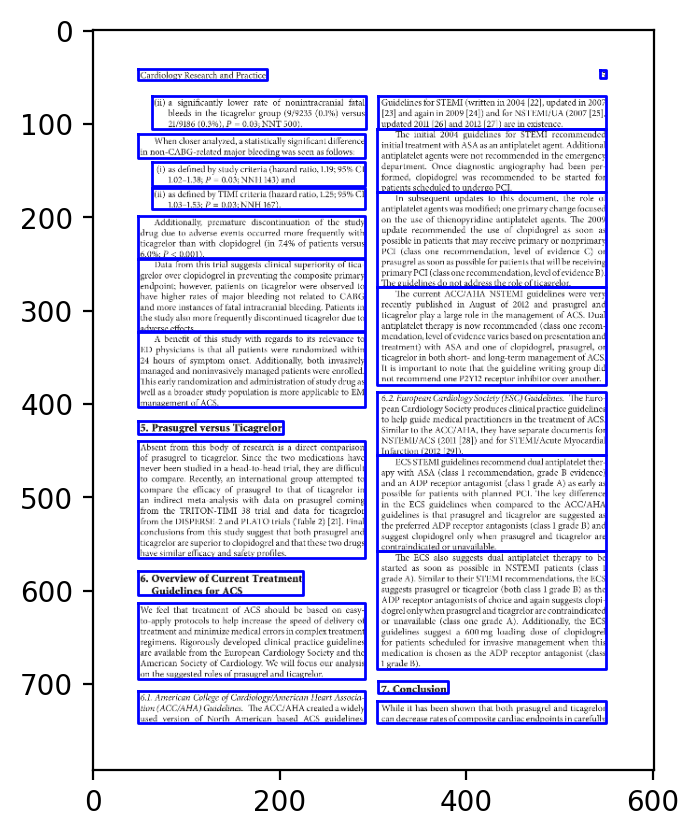

In [70]:
import matplotlib.pyplot as plt
plt.figure(dpi=200)
num = 68
js, img = pred.get_json_and_img(test_dataset[num]['path'])
regs = pipeline(test_dataset[num]['path'])['regions']
for reg in regs:
    r =Region(segment=reg['segment'], children=reg['rows'], data={'label': reg['label']})
    r.segment.plot()
ploter.plot_img(img)

In [68]:
test_dataset[2]

{'bboxes_true': [{'x_top_left': 50,
   'y_top_left': 391,
   'height': 78,
   'width': 240},
  {'x_top_left': 308, 'y_top_left': 391, 'height': 21, 'width': 240},
  {'x_top_left': 50, 'y_top_left': 470, 'height': 272, 'width': 240},
  {'x_top_left': 308, 'y_top_left': 415, 'height': 90, 'width': 240},
  {'x_top_left': 308, 'y_top_left': 550, 'height': 192, 'width': 240},
  {'x_top_left': 50, 'y_top_left': 282, 'height': 72, 'width': 498},
  {'x_top_left': 52, 'y_top_left': 72, 'height': 200, 'width': 494},
  {'x_top_left': 308, 'y_top_left': 528, 'height': 12, 'width': 117}],
 'classes_true': [1, 1, 1, 1, 1, 1, 5, 2],
 'path': PosixPath('/home/daniil/disk01_1TB/datasets/micro_publaynet_5/pdfs/dev/PMC2777011_00008.pdf')}

In [69]:
regs

[{'segment': {'x_top_left': 52,
   'y_top_left': 69,
   'x_bottom_right': 300,
   'y_bottom_right': 257},
  'label': 5,
  'rows': []},
 {'segment': {'x_top_left': 309,
   'y_top_left': 70,
   'x_bottom_right': 557,
   'y_bottom_right': 257},
  'label': 5,
  'rows': []},
 {'segment': {'x_top_left': 47,
   'y_top_left': 389,
   'x_bottom_right': 296,
   'y_bottom_right': 469},
  'label': 1,
  'rows': []},
 {'segment': {'x_top_left': 48,
   'y_top_left': 469,
   'x_bottom_right': 297,
   'y_bottom_right': 742},
  'label': 1,
  'rows': []},
 {'segment': {'x_top_left': 309,
   'y_top_left': 389,
   'x_bottom_right': 559,
   'y_bottom_right': 411},
  'label': 1,
  'rows': []},
 {'segment': {'x_top_left': 309,
   'y_top_left': 413,
   'x_bottom_right': 560,
   'y_bottom_right': 506},
  'label': 1,
  'rows': []},
 {'segment': {'x_top_left': 310,
   'y_top_left': 527,
   'x_bottom_right': 436,
   'y_bottom_right': 540},
  'label': 1,
  'rows': []},
 {'segment': {'x_top_left': 309,
   'y_top_lef

[{'type': 'chart',
  'img_path': 'images/8d75f803d73ba4d106d25e09bd431cb46e98bb6f56242a6f4a153270f786125e.jpg',
  'content': '| T0    | T5    | Color  |\n|-------|-------|--------|\n| 0.01  | 0.1   | Yellow |\n| 0.1   | 1     | Yellow |\n| 1     | 10    | Blue   |\n| 10    | 100   | Red    |\n| 100   | 1000  | Red    |\n| 1000  | 10000 | Red    |',
  'chart_caption': ['(a) '],
  'chart_footnote': [],
  'sub_type': 'scatter',
  'bbox': [85, 88, 491, 325],
  'page_idx': 0},
 {'type': 'chart',
  'img_path': 'images/1374bc8da312067636abaca3d045a7ed40d80354c896750262772129163868d3.jpg',
  'content': '| T0    | T5    | Group |\n|-------|-------|-------|\n| 1     | 1     | Blue  |\n| 10    | 10    | Red   |\n| 100   | 100   | Red   |\n| 1000  | 1000  | Red   |\n| 10000 | 10000 | Red   |\n| 1     | 1     | Yellow|\n| 10    | 1     | Yellow|\n| 100   | 1     | Yellow|\n| 1000  | 1     | Yellow|\n| 10000 | 1     | Yellow|',
  'chart_caption': ['(b) ',
   'Figure 4: Degradation profiles of S. aur

In [67]:
test_dataset.coco_manager.classes

{1: 'text', 2: 'title', 3: 'list', 4: 'table', 5: 'figure', 0: 'other'}

In [28]:
times = """
TIME: 5.7924
TIME: 4.2895
TIME: 7.5373
TIME: 5.8384
TIME: 5.4191
TIME: 8.3675
TIME: 3.0665
TIME: 4.2854
TIME: 4.1261
TIME: 2.9229
TIME: 3.0295
TIME: 2.5617
TIME: 2.6987
TIME: 2.8423
TIME: 4.4839
TIME: 2.8046
TIME: 3.4770
TIME: 2.6113
TIME: 2.5106
TIME: 3.2129
TIME: 2.8249
TIME: 6.1844
TIME: 3.4585
TIME: 6.1557
TIME: 2.7620
TIME: 2.3807
TIME: 5.4236
TIME: 2.8263
TIME: 3.6280
TIME: 4.6147
TIME: 3.0356
TIME: 4.1826
TIME: 6.2574
TIME: 3.6416
TIME: 3.2429
TIME: 3.4037
TIME: 3.0544
TIME: 2.9373
TIME: 4.1359
TIME: 2.8220
TIME: 2.5775
TIME: 4.7387
TIME: 3.4076
TIME: 2.9456
TIME: 4.9444
TIME: 4.2784
TIME: 3.1355
TIME: 5.1666
TIME: 4.5333
TIME: 3.7471
TIME: 3.9938
TIME: 2.5491
TIME: 6.9400
TIME: 4.5569
TIME: 2.6796
TIME: 2.8155
TIME: 4.6180
TIME: 3.9633
TIME: 10.9000
TIME: 3.0986
TIME: 5.0106
TIME: 2.7459
TIME: 3.4422
TIME: 3.7144
TIME: 5.4602
TIME: 3.5339
TIME: 3.3399
TIME: 3.2677
TIME: 3.6188
TIME: 4.5935
TIME: 6.2694
TIME: 5.0892
TIME: 4.0290
TIME: 2.5965
TIME: 3.8372
TIME: 3.8729
TIME: 1.7804
TIME: 3.5850
TIME: 6.6063
TIME: 3.7075
TIME: 4.0528
TIME: 5.4805
TIME: 4.6627
TIME: 7.7454
TIME: 8.4323
TIME: 4.5014
TIME: 4.4725
TIME: 4.0008
TIME: 5.1126
TIME: 5.3850
TIME: 3.0946
TIME: 4.6436
TIME: 4.5458
TIME: 3.2312
TIME: 4.0842
TIME: 3.3578
TIME: 3.6373
TIME: 6.1535
TIME: 2.6647
TIME: 3.7854
TIME: 4.3069
TIME: 4.0800
TIME: 3.3819
TIME: 3.6238
TIME: 3.3048
TIME: 2.4079
TIME: 4.1280
TIME: 5.5508
TIME: 5.6843
TIME: 12.8181
TIME: 3.7173
TIME: 2.6376
TIME: 3.9420
TIME: 4.1182
TIME: 4.4720
TIME: 6.4901
TIME: 4.6766
TIME: 5.8671
TIME: 3.4696
TIME: 3.5827
TIME: 4.3242
TIME: 2.8795
TIME: 4.3670
TIME: 4.4052
TIME: 5.1318
TIME: 5.5289
TIME: 2.8158
TIME: 6.2007
TIME: 4.2504
TIME: 4.6282
TIME: 3.2731
TIME: 3.3026
TIME: 5.8892
TIME: 4.8424
TIME: 9.0440
TIME: 3.9254
TIME: 5.0567
TIME: 4.1979
TIME: 2.5835
TIME: 3.9947
TIME: 4.2044
TIME: 4.4677
TIME: 4.9550
TIME: 4.3871
TIME: 4.9444
TIME: 2.7648
TIME: 5.7708
TIME: 3.5687
TIME: 4.3204
TIME: 6.2582
TIME: 4.6306
TIME: 2.9908
TIME: 10.6892
TIME: 4.6945
TIME: 2.8912
TIME: 3.9233
TIME: 5.3056
TIME: 5.4864
TIME: 5.4502
TIME: 9.4928
TIME: 4.2580
TIME: 3.2987
TIME: 4.6604
TIME: 5.8692
TIME: 3.9337
TIME: 3.0334
TIME: 3.1616
TIME: 4.6101
TIME: 3.5448
TIME: 10.0870
TIME: 4.9846
TIME: 4.7732
TIME: 8.6855
TIME: 1.7496
TIME: 2.3013
TIME: 6.3547
TIME: 4.1005
TIME: 3.9925
TIME: 4.0901
TIME: 3.3395
TIME: 2.1181
TIME: 4.1531
TIME: 8.1934
TIME: 3.0182
TIME: 12.6566
TIME: 4.6591
TIME: 3.8653
TIME: 3.3004
TIME: 4.0193
TIME: 3.4983
TIME: 4.5149
TIME: 4.0309
TIME: 3.1471
TIME: 4.3824
TIME: 3.9699
TIME: 7.7294
TIME: 8.7733
TIME: 3.3737
TIME: 6.7375
TIME: 4.7924
"""

In [29]:
import numpy as np
np.mean([float(t) for t in times.split()[1::2]]), np.median([float(t) for t in times.split()[1::2]])

(np.float64(4.467213), np.float64(4.0953))

In [ ]:
'time(median/mean)': 4.46/4.09
'mAP (all)': 0.35839012265205383,
'mAP (seg)': 0.3886750340461731,
8gb видео памяти

In [15]:
from pager.page_model.sub_models import RegionModel, RowsModel
from rows2regionsGLAM.pipeline.converters import Rows2Regions

class Pipeline2:
    def __init__(self, pred, model, dataset_name2id, model_id2name):
        self.pred = pred
        self.model = model
        
        self.rows_model = RowsModel()
        self.region_model = RegionModel()
        self.rows2regions = Rows2Regions({
            'model':model, 
            'tokenizer': pred.tokenizer,
            'is_merge_extract': True,
            'classes': model_id2name
        })
        self.name2id = dataset_name2id
        
        

    def __call__(self, path):
        st = time.time()
        pdf_json, pdf_img = self.pred.get_json_and_img(path)
        row_json = pdf_json['rows']
        self.rows_model.from_dict({"rows": row_json})
        self.rows2regions.convert(self.rows_model, self.region_model, pdf_img)
        print(f'TIME: {time.time()-st:.4f}')
        pred_regions = self.region_model.to_dict()['regions']
        def name2id(r):
            r['label'] = self.name2id[r['label']]
            return r
            
        filtered_preds = [name2id(r) for r in pred_regions]
        return {
            "regions": filtered_preds
        }

In [19]:
model_params = {
"node_block":	{'linear_pred': [{'in': 15, 'out': 256, 'activation': 'gelu'}, {'in': 256, 'out': 512, 'activation': 'gelu'}], 'gnn': [('tag', {'batch_norm': True, 'concat': True, 'in': 512, 'in_gnn': 1024, 'out_gnn': 512, 'gnn_activation': 'gelu', 'activation': 'gelu', 'K': 3}), ('tag', {'batch_norm': False, 'concat': True, 'in': 1024, 'in_gnn': 1024, 'out_gnn': 512, 'gnn_activation': 'gelu', 'activation': 'gelu', 'K': 3})]},
"node_classifier_block":	{'linear_post': [{'in': 1536, 'out': 512, 'activation': 'gelu'}, {'in': 512, 'out': 64, 'activation': 'gelu'}, {'in': 64, 'out': 6, 'activation': 'softmax'}]},
"post_node_block":	{'linear_pred': [{'in': 1536, 'out': 1024, 'activation': 'gelu'}, {'in': 1024, 'out': 512, 'activation': 'gelu'}, {'in': 512, 'out': 256, 'activation': 'gelu'}], 'gnn': [('tag', {'batch_norm': True, 'concat': True, 'in': 256, 'in_gnn': 256, 'out_gnn': 256, 'gnn_activation': 'gelu', 'activation': 'gelu', 'K': 3}), ('tag', {'batch_norm': False, 'concat': True, 'in': 512, 'in_gnn': 256, 'out_gnn': 128, 'gnn_activation': 'gelu', 'activation': 'gelu', 'K': 3})]},
"edge_classifier_block":	{'linear_post': [{'in': 1314, 'out': 128, 'activation': 'gelu'}, {'in': 128, 'out': 32, 'activation': 'gelu'}, {'in': 32, 'out': 1, 'activation': 'sigmoid'}]},
"seg_k":	0.5
            
        }
from rows2regionsGLAM.models import get_model

model, _ = get_model(model_params, '/home/daniil/disk01_1TB/sources/programs/rows2regionsGLAM/experiments/big_model/result_epoch_coef_1_20260528/row2region_GLAM_start_no_0_tmp_9')

model_id2name = test_dataset.coco_manager.classes
dataset_name2id = {val:key for key, val in model_id2name.items()}
pipeline = Pipeline2(pred=pred, model=model, dataset_name2id=dataset_name2id, model_id2name=model_id2name)

tester = Tester(pipeline=pipeline, dataset=test_dataset, loger=loger)
tester.calculate()
grid_cls, map_cls = tester.get_results()
rez = {**grid_cls, **map_cls}
rez

/home/daniil/disk01_1TB/sources/programs/PageR/env/lib/python3.13/site-packages/torch_geometric/utils/_spmm.py:71: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  src = src.to_sparse_csr()


TIME: 0.3074
TIME: 0.3865
TIME: 0.3497
TIME: 0.7346
TIME: 0.2867
TIME: 0.2351
TIME: 0.2352
TIME: 0.2891
TIME: 0.2423
TIME: 0.1629
TIME: 0.1598
TIME: 0.2231
TIME: 0.1592
TIME: 0.2453
TIME: 0.1837
TIME: 0.1567
TIME: 0.1666
TIME: 0.1583
TIME: 0.1670
TIME: 0.2401
TIME: 0.2163
TIME: 0.2062
TIME: 0.1479
TIME: 0.2418
TIME: 0.2386
TIME: 0.2310
TIME: 0.2284
TIME: 0.1550
TIME: 0.1872
TIME: 0.6651
TIME: 0.1529
TIME: 0.4866
TIME: 0.2815
TIME: 0.3812
TIME: 0.4452
TIME: 0.2179
TIME: 0.1845
TIME: 0.1601
TIME: 0.2441
TIME: 0.2198
TIME: 0.1602
TIME: 0.2599
TIME: 0.1583
TIME: 0.1522
TIME: 0.2804
TIME: 4.0610
TIME: 0.1493
TIME: 0.2297
TIME: 0.4540
TIME: 0.1744
TIME: 0.1803
TIME: 0.1514
TIME: 0.2849
TIME: 0.2856
TIME: 0.1460
TIME: 0.1436
TIME: 0.3029
TIME: 0.2463
TIME: 0.4795
TIME: 0.2192
TIME: 0.2734
TIME: 0.2626
TIME: 0.1549
TIME: 0.1899
TIME: 0.2290
TIME: 0.2935
TIME: 0.2331
TIME: 0.2361
TIME: 0.2309
TIME: 0.2493
TIME: 0.2598
35.50 %

Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P2' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value


TIME: 0.3003
36.00 %

Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P2' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value


...

Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P2' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value


TIME: 0.2150
54.50 %

Cannot set gray non-stroke color because /'P4' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value
Cannot set gray non-stroke color because /'P5' is an invalid float value
Cannot set gray non-stroke color because /'P5' is an invalid float value
Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P2' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value
Cannot set gray non-stroke color because /'P4' is an invalid float value
Cannot set gray non-stroke color because /'P5' is an invalid float value
Cannot set gray non-stroke color because /'P5' is an invalid float value


TIME: 0.6985
TIME: 0.2866
TIME: 0.1489
TIME: 0.5813
TIME: 0.1815
TIME: 0.3005
TIME: 0.6394
TIME: 0.2563
TIME: 0.1619
TIME: 0.1437
TIME: 0.1976
TIME: 0.6238
TIME: 0.1436
TIME: 0.1706
TIME: 0.3652
TIME: 0.3948
TIME: 0.2520
TIME: 0.2540
TIME: 0.2089
TIME: 0.1457
TIME: 0.2316
TIME: 0.2287
TIME: 0.3108
TIME: 0.2196
TIME: 0.3199
TIME: 0.2295
TIME: 0.2556
TIME: 0.5367
TIME: 0.1634
TIME: 0.4042
TIME: 0.2214
TIME: 0.1791
TIME: 0.2047
TIME: 1.0204
TIME: 0.3904
TIME: 0.2796
TIME: 0.1589
TIME: 96.9911
TIME: 0.2298
TIME: 0.1977
TIME: 0.3757
TIME: 0.3144
TIME: 0.2072
TIME: 0.1857
TIME: 0.4055
TIME: 0.2198
TIME: 0.1336
TIME: 0.1597
TIME: 0.2113
TIME: 0.2256
TIME: 0.6822
TIME: 0.2671
TIME: 0.1356
TIME: 0.2853
TIME: 0.2660
TIME: 1.2701
TIME: 0.2300
TIME: 0.2239
TIME: 0.2428
TIME: 0.2256
TIME: 0.4894
TIME: 0.2785
TIME: 0.1833
TIME: 0.2968
TIME: 0.1458
TIME: 0.1482
TIME: 0.2042
TIME: 0.2368
TIME: 0.2058
TIME: 0.2496
TIME: 0.1928
TIME: 0.2122
TIME: 0.2607
TIME: 0.2806
TIME: 0.1844
TIME: 0.1237
TIME: 0.181

{'threshold_0.5 (0)': np.float64(0.0),
 'threshold_0.95 (0)': np.float64(0.0),
 'threshold_0.5 (1)': np.float64(0.8571663785258837),
 'threshold_0.95 (1)': np.float64(0.8412009705970892),
 'threshold_0.5 (2)': np.float64(0.9124130036630036),
 'threshold_0.95 (2)': np.float64(0.907496336996337),
 'threshold_0.5 (3)': np.float64(0.7998412698412699),
 'threshold_0.95 (3)': np.float64(0.7744126984126984),
 'threshold_0.5 (4)': np.float64(0.9295476190476191),
 'threshold_0.95 (4)': np.float64(0.8946904761904761),
 'threshold_0.5 (5)': np.float64(0.7359166666666667),
 'threshold_0.95 (5)': np.float64(0.72225),
 'threshold_0.5 (all)': np.float64(0.7768871507551093),
 'threshold_0.95 (all)': np.float64(0.7497497606867194),
 'name': 'mAP@IoU[0.50:0.95]',
 'mAP (all)': 0.5319899320602417,
 'mAP (seg)': 0.5840654969215393,
 'mAP (other)': -1.0,
 'mAP (text)': 0.7161715030670166,
 'mAP (title)': 0.5597226619720459,
 'mAP (list)': 0.3050355911254883,
 'mAP (table)': 0.5073010921478271,
 'mAP (figur

In [21]:
times = """
TIME: 0.3074
TIME: 0.3865
TIME: 0.3497
TIME: 0.7346
TIME: 0.2867
TIME: 0.2351
TIME: 0.2352
TIME: 0.2891
TIME: 0.2423
TIME: 0.1629
TIME: 0.1598
TIME: 0.2231
TIME: 0.1592
TIME: 0.2453
TIME: 0.1837
TIME: 0.1567
TIME: 0.1666
TIME: 0.1583
TIME: 0.1670
TIME: 0.2401
TIME: 0.2163
TIME: 0.2062
TIME: 0.1479
TIME: 0.2418
TIME: 0.2386
TIME: 0.2310
TIME: 0.2284
TIME: 0.1550
TIME: 0.1872
TIME: 0.6651
TIME: 0.1529
TIME: 0.4866
TIME: 0.2815
TIME: 0.3812
TIME: 0.4452
TIME: 0.2179
TIME: 0.1845
TIME: 0.1601
TIME: 0.2441
TIME: 0.2198
TIME: 0.1602
TIME: 0.2599
TIME: 0.1583
TIME: 0.1522
TIME: 0.2804
TIME: 4.0610
TIME: 0.1493
TIME: 0.2297
TIME: 0.4540
TIME: 0.1744
TIME: 0.1803
TIME: 0.1514
TIME: 0.2849
TIME: 0.2856
TIME: 0.1460
TIME: 0.1436
TIME: 0.3029
TIME: 0.2463
TIME: 0.4795
TIME: 0.2192
TIME: 0.2734
TIME: 0.2626
TIME: 0.1549
TIME: 0.1899
TIME: 0.2290
TIME: 0.2935
TIME: 0.2331
TIME: 0.2361
TIME: 0.2309
TIME: 0.2493
TIME: 0.2598
TIME: 0.3003
TIME: 0.2898
TIME: 0.1708
TIME: 0.2413
TIME: 0.2018
TIME: 0.2934
TIME: 0.2079
TIME: 9.8712
TIME: 0.2267
TIME: 0.2106
TIME: 0.2355
TIME: 0.2235
TIME: 0.2730
TIME: 0.4390
TIME: 0.2368
TIME: 0.2206
TIME: 0.4251
TIME: 0.7501
TIME: 0.2131
TIME: 0.2508
TIME: 0.2425
TIME: 0.2027
TIME: 0.2293
TIME: 0.2093
TIME: 0.2206
TIME: 0.2075
TIME: 2.1822
TIME: 0.1848
TIME: 0.2182
TIME: 0.2383
TIME: 0.2093
TIME: 0.1740
TIME: 0.2118
TIME: 0.1718
TIME: 0.3667
TIME: 0.2002
TIME: 0.1323
TIME: 0.2150
TIME: 0.6985
TIME: 0.2866
TIME: 0.1489
TIME: 0.5813
TIME: 0.1815
TIME: 0.3005
TIME: 0.6394
TIME: 0.2563
TIME: 0.1619
TIME: 0.1437
TIME: 0.1976
TIME: 0.6238
TIME: 0.1436
TIME: 0.1706
TIME: 0.3652
TIME: 0.3948
TIME: 0.2520
TIME: 0.2540
TIME: 0.2089
TIME: 0.1457
TIME: 0.2316
TIME: 0.2287
TIME: 0.3108
TIME: 0.2196
TIME: 0.3199
TIME: 0.2295
TIME: 0.2556
TIME: 0.5367
TIME: 0.1634
TIME: 0.4042
TIME: 0.2214
TIME: 0.1791
TIME: 0.2047
TIME: 1.0204
TIME: 0.3904
TIME: 0.2796
TIME: 0.1589
TIME: 96.9911
TIME: 0.2298
TIME: 0.1977
TIME: 0.3757
TIME: 0.3144
TIME: 0.2072
TIME: 0.1857
TIME: 0.4055
TIME: 0.2198
TIME: 0.1336
TIME: 0.1597
TIME: 0.2113
TIME: 0.2256
TIME: 0.6822
TIME: 0.2671
TIME: 0.1356
TIME: 0.2853
TIME: 0.2660
TIME: 1.2701
TIME: 0.2300
TIME: 0.2239
TIME: 0.2428
TIME: 0.2256
TIME: 0.4894
TIME: 0.2785
TIME: 0.1833
TIME: 0.2968
TIME: 0.1458
TIME: 0.1482
TIME: 0.2042
TIME: 0.2368
TIME: 0.2058
TIME: 0.2496
TIME: 0.1928
TIME: 0.2122
TIME: 0.2607
TIME: 0.2806
TIME: 0.1844
TIME: 0.1237
TIME: 0.1817
TIME: 0.1402
TIME: 0.1454
TIME: 0.2455
TIME: 0.2349
TIME: 0.1066
TIME: 0.1723
TIME: 0.1658
TIME: 0.1484
TIME: 0.1652
TIME: 0.3759
TIME: 0.1935
TIME: 1.4531
TIME: 103.1262
TIME: 0.1432
"""

In [25]:
np.mean([float(t) for t in times.split()[1::2]]),np.median([float(t) for t in times.split()[1::2]])

(np.float64(1.3424785), np.float64(0.22915000000000002))

In [ ]:
'time(median/mean)': 0.22/1.34
'mAP (all)': 0.5319899320602417,
'mAP (seg)': 0.5840654969215393,
174MB видео памяти

In [ ]:
# ИТОГИ
MinerU
'time(median/mean)': 4.46/4.09
'mAP (all)': 0.42,
 'mAP (seg)': 0.48,
'GPU': 8GB

GLAM
'time(median/mean)': 0.22/1.34
'mAP (all)': 0.53,
'mAP (seg)': 0.58,
'GPU': 174MB